# 04 · Models

**Goal:** how well can we predict, at the moment a disruption is announced, whether it will last 90 minutes or more?

- **Input:** `data/processed/model_table.parquet` (from notebook 03)
- **Plan:** compare simple baselines and two models on **2024** (validation), choose, then test **once** on **2025**.
- **Metrics** (all on predicted probabilities, via `src/evaluate.py`):
  - **ROC-AUC**: does the model rank long disruptions above short ones? 0.5 = random, 1 = perfect.
  - **PR-AUC**: how precise is the top of the list, i.e. the disruptions we would flag as long?
    No-skill level = the long rate (0.345 in 2024).
  - **Brier score**: are the probabilities themselves honest? Lower is better; 0 = perfect.

## 1. Setup and data

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from src.evaluate import evaluate

processed_dir = repo_root / "data" / "processed"
df = pd.read_parquet(processed_dir / "model_table.parquet")
df.shape

(37305, 111)

In [2]:
df["split"].value_counts()

split
train    24968
test      6517
valid     5820
Name: count, dtype: int64

In [3]:
line_cols = [c for c in df.columns if c.startswith("line_")]
categorical = ["cause", "cause_group", "start_hour"]
other = ["is_weekend", "n_lines"] + line_cols
features = categorical + other

X_train = df.loc[df["split"] == "train", features]
X_valid = df.loc[df["split"] == "valid", features]
y_train = df.loc[df["split"] == "train", "long"]
y_valid = df.loc[df["split"] == "valid", "long"]

print("Features:", len(features), "| train:", X_train.shape, "| valid:", X_valid.shape)

Features: 108 | train: (24968, 108) | valid: (5820, 108)


The test year (2025) is **not** loaded here on purpose: it is only touched once, in the final step.

`start_hour` is treated as a **category**, not a number. The hour does not affect the long rate in a straight line
(23% at 0h, 83% at 3h, 34% during the day, 25% in the evening), so every hour gets its own weight.

## 2. Checking the metric function

A function that every result depends on is first checked on a tiny case where the answer is known by hand:

In [4]:
# Expected: ROC-AUC 0.75 (3 of 4 long/short pairs ranked correctly), PR-AUC 0.83, Brier 0.165
evaluate([1, 1, 0, 0], [0.8, 0.4, 0.5, 0.1], "hand-made example")

{'model': 'hand-made example',
 'roc_auc': 0.75,
 'pr_auc': 0.8333333333333333,
 'brier': 0.16499999999999998}

## 3. Baselines

**(a) Dummy:** predicts the training long rate for every disruption. Anything worse is useless.

In [5]:
dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train, y_train)
prob_dummy = dummy.predict_proba(X_valid)[:, 1]

results = []
results.append(evaluate(y_valid, prob_dummy, "dummy (prior)"))

**(b) Cause lookup:** every 2024 disruption gets the long rate its cause had in 2019–2023. No machine learning,
just one `groupby` from the EDA: the common-sense benchmark a model has to beat.

In [6]:
cause_rates = df.loc[df["split"] == "train"].groupby("cause")["long"].mean()
prob_cause = X_valid["cause"].map(cause_rates)

assert prob_cause.isna().sum() == 0   # every 2024 cause exists in train (rare/unseen ones are "other")
results.append(evaluate(y_valid, prob_cause, "cause lookup"))

pd.DataFrame(results).round(3)

,model,roc_auc,pr_auc,brier
0,dummy (prior),0.500,0.345,0.226
1,cause lookup,0.809,0.668,0.158


The dummy scores exactly the no-skill levels (ROC-AUC 0.5, PR-AUC = the 2024 long rate 0.345, Brier 0.226), which
also confirms that the split and the metric function are right.

The cause lookup alone takes ROC-AUC from 0.50 to **0.81** and nearly doubles PR-AUC (0.345 → **0.67**): the cause
is by far the strongest signal. This is the bar the models have to beat. What the lookup cannot see is the hour
and the line: it gives every broken-down train the same probability, while notebook 02 showed that one starting at
3 a.m. is long 80% of the time against 15% during the day.

## 4. Logistic regression

A `Pipeline` chains the preprocessing and the model, so `.fit()` and `.predict_proba()` run both steps.
The `ColumnTransformer` one-hot encodes the categorical columns and passes the 0/1 and count columns through.

The encoder sits **inside** the pipeline, so it learns its list of categories from the training rows only and
reuses exactly that list for 2024 and 2025 (the same "decide on train, apply to all" rule as in notebook 03).
`handle_unknown="ignore"` means a category never seen in training gets all zeros instead of crashing the model.

In [7]:
preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("other", "passthrough", other),
])

logreg = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000)),
])

logreg.fit(X_train, y_train)
prob_logreg = logreg.predict_proba(X_valid)[:, 1]
results.append(evaluate(y_valid, prob_logreg, "logistic regression"))

pd.DataFrame(results).round(3)

,model,roc_auc,pr_auc,brier
0,dummy (prior),0.500,0.345,0.226
1,cause lookup,0.809,0.668,0.158
2,logistic regression,0.823,0.708,0.155


Logistic regression beats the cause lookup on every metric: ROC-AUC +0.014, PR-AUC +0.04, Brier slightly lower.
The gain comes from what the lookup cannot see: hour, lines and weekend.

## 5. LightGBM

Logistic regression **adds up** separate effects ("collision adds this much, 3 a.m. adds that much"). It cannot learn
by itself that 3 a.m. matters a lot for a broken-down train but works the other way for accidents. LightGBM builds
many small decision trees; a tree can first split on the cause and then, *inside* that branch, split on the hour, so
combinations like "rolling stock **and** night" are learned automatically.

In [8]:
lgbm = Pipeline([
    ("prep", preprocessor),
    ("model", LGBMClassifier(random_state=42, verbose=-1)),
])

lgbm.fit(X_train, y_train)
prob_lgbm = lgbm.predict_proba(X_valid)[:, 1]
results.append(evaluate(y_valid, prob_lgbm, "lightgbm (default)"))

**A small search.** Six settings: tree complexity (`num_leaves`) × number of trees (`n_estimators`), with a fixed
learning rate. They are compared on 2024 only. The probabilities are kept so the chosen setting can be compared with
logistic regression afterwards.

In [9]:
grid_results = []
grid_probs = {}
grid_params = {}

for leaves in [15, 31, 63]:
    for trees in [200, 500]:
        lgbm_candidate = Pipeline([
            ("prep", preprocessor),
            ("model", LGBMClassifier(
                num_leaves=leaves,
                n_estimators=trees,
                learning_rate=0.05,
                random_state=42,
                verbose=-1,
            )),
        ])
        lgbm_candidate.fit(X_train, y_train)
        prob_candidate = lgbm_candidate.predict_proba(X_valid)[:, 1]

        name = f"lightgbm leaves={leaves} trees={trees}"
        grid_results.append(evaluate(y_valid, prob_candidate, name))
        grid_probs[name] = prob_candidate
        grid_params[name] = {"num_leaves": leaves, "n_estimators": trees}

grid_table = pd.DataFrame(grid_results).sort_values("pr_auc", ascending=False)
grid_table.round(4)

,model,roc_auc,pr_auc,brier
1,lightgbm leaves=15 trees=500,0.8283,0.7152,0.1535
0,lightgbm leaves=15 trees=200,0.8276,0.7133,0.1536
4,lightgbm leaves=63 trees=200,0.8292,0.7133,0.1540
2,lightgbm leaves=31 trees=200,0.8289,0.7125,0.1535
3,lightgbm leaves=31 trees=500,0.8279,0.7111,0.1548
5,lightgbm leaves=63 trees=500,0.8251,0.7104,0.1571


All six settings land within about 0.004 of each other on every metric: **the settings barely matter**. The selection
rule is fixed in advance: the highest **PR-AUC**, because the practical use is the top of the list (the disruptions
we would flag as long). That is `leaves=15, trees=500`, which also shares the best Brier score.

In [10]:
best_name = grid_table.iloc[0]["model"]
prob_lgbm_best = grid_probs[best_name]

results.append(evaluate(y_valid, prob_lgbm_best, best_name))
results_table = pd.DataFrame(results)
results_table.round(3)

,model,roc_auc,pr_auc,brier
0,dummy (prior),0.500,0.345,0.226
1,cause lookup,0.809,0.668,0.158
2,logistic regression,0.823,0.708,0.155
3,lightgbm (default),0.828,0.712,0.154
4,lightgbm leaves=15 trees=500,0.828,0.715,0.154


## 6. Choosing the model for the final test

LightGBM is slightly ahead on all three metrics. Is that a real difference or luck in which disruptions happened to
fall in 2024? A **bootstrap** answers this: resample the 2024 disruptions with replacement 1,000 times, recompute
the difference each time, and look at the middle 95% of the differences. If that interval contains 0, the
difference could be luck.

In [11]:
rng = np.random.default_rng(42)
y = y_valid.to_numpy()
diffs = {"roc_auc": [], "pr_auc": []}

for _ in range(1000):
    idx = rng.integers(0, len(y), len(y))
    diffs["roc_auc"].append(roc_auc_score(y[idx], prob_lgbm_best[idx]) - roc_auc_score(y[idx], prob_logreg[idx]))
    diffs["pr_auc"].append(
        average_precision_score(y[idx], prob_lgbm_best[idx]) - average_precision_score(y[idx], prob_logreg[idx])
    )

pd.DataFrame({
    metric: {
        "difference (LightGBM − logistic regression)": np.mean(values),
        "95% interval low": np.percentile(values, 2.5),
        "95% interval high": np.percentile(values, 97.5),
    }
    for metric, values in diffs.items()
}).T.round(4)

,difference (LightGBM − logistic regression),95% interval low,95% interval high
roc_auc,0.0057,0.0014,0.0106
pr_auc,0.0068,-0.0005,0.0146


**Decision (made before looking at 2025):**

- LightGBM (`leaves=15, trees=500`) is the **main model**. Its ROC-AUC gain over logistic regression is small (about
  +0.006) but the bootstrap interval stays above 0; the PR-AUC gain (about +0.007) is just as small and its interval
  touches 0.
- Logistic regression is kept as the **reference model** in the final test: it is simpler, easier to explain and
  almost as good. Both are fixed now, so reporting both on 2025 is not cherry-picking.
- Honest conclusion so far: almost all of the predictive power comes from the **cause**; hour, lines and the
  extra flexibility of LightGBM add a little on top.

## 7. Inside the chosen models (still on 2024)

### Calibration

The metrics above mostly judge the *ranking*. Calibration checks the probabilities themselves: the 2024 disruptions
are grouped into 10 bins by predicted probability, and for each bin the average prediction is compared with the share
that really was long. A perfectly calibrated model lies on the diagonal.

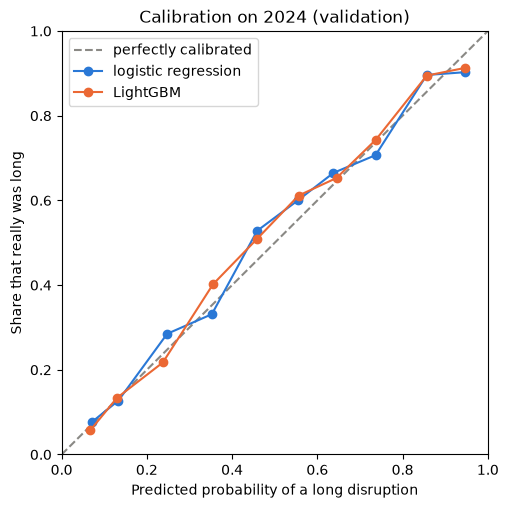

In [12]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

figures_dir = repo_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], linestyle="--", color="#8a8985", label="perfectly calibrated")

for prob, label, color in [
    (prob_logreg, "logistic regression", "#2a78d6"),
    (prob_lgbm_best, "LightGBM", "#eb6834"),
]:
    share_long, mean_pred = calibration_curve(y_valid, prob, n_bins=10)
    ax.plot(mean_pred, share_long, marker="o", color=color, label=label)

ax.set_xlabel("Predicted probability of a long disruption")
ax.set_ylabel("Share that really was long")
ax.set_title("Calibration on 2024 (validation)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
fig.savefig(figures_dir / "04_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

Both models are **well calibrated** on 2024: the points stay close to the diagonal across the whole range. Between
about 35% and 55% predicted, the real share is a few points higher than predicted, so in that range the models
slightly **under**-estimate the risk of a long disruption. The probabilities can be read as honest percentages,
which matters if they are shown to someone ("70% chance this lasts 90+ minutes").

### Subgroups

Notebooks 02 and 03 pointed at three groups where the model could struggle: the growing `technical investigation`
category, night starts, and the four causes that became more often long in 2024. For each group: the real long rate,
the average predicted probability, and how well the model ranks within the group.

In [13]:
JUMPED_CAUSES = ["repair works", "damaged railway bridge", "signal failure", "points failure"]


def subgroup_report(X, y, prob, groups):
    rows = []
    for name, mask in groups.items():
        mask = np.asarray(mask)
        y_group, prob_group = np.asarray(y)[mask], prob[mask]
        rows.append({
            "group": name,
            "n": int(mask.sum()),
            "real long rate": y_group.mean(),
            "mean prediction": prob_group.mean(),
            "roc_auc": roc_auc_score(y_group, prob_group) if 0 < y_group.mean() < 1 else np.nan,
        })
    return pd.DataFrame(rows).set_index("group")


def define_groups(X):
    groups = {
        "all": np.ones(len(X), dtype=bool),
        "technical investigation": X["cause"] == "technical investigation",
        "night start (1–5h)": X["start_hour"].between(1, 5),
        "the four jumped causes": X["cause"].isin(JUMPED_CAUSES),
    }
    for cause in JUMPED_CAUSES:
        groups[f"  {cause}"] = X["cause"] == cause
    return groups


subgroup_report(X_valid, y_valid, prob_lgbm_best, define_groups(X_valid)).round(3)

,n,real long rate,mean prediction,roc_auc
group,,,,
all,5820,0.345,0.333,0.828
technical investigation,242,0.128,0.168,0.437
night start (1–5h),295,0.725,0.669,0.772
the four jumped causes,936,0.625,0.538,0.587
repair works,78,0.731,0.544,0.752
damaged railway bridge,125,0.504,0.395,0.495
signal failure,448,0.643,0.561,0.559
points failure,285,0.621,0.561,0.577


- **The four causes that jumped in 2024** are under-predicted, as expected from the stability check in notebook 03:
  62.5% were really long against an average prediction of 54%. `repair works` is off the most (73% real vs 54%
  predicted). The model learned the 2019–2023 rates and cannot know that these causes changed.
- **Night starts** are also slightly under-predicted (72.5% real vs 67% predicted), but ranked reasonably well
  within the group (ROC-AUC 0.77).
- **`technical investigation`** is predicted at about the right level (17% vs 13%), but *within* this group the model
  cannot rank at all (ROC-AUC 0.44, no better than chance). That makes sense: "under investigation" says nothing about
  what actually broke, so only the hour and the line are left to go on.
- Within a single cause the ranking is generally weak (ROC-AUC 0.5–0.75): most of the model's skill comes from telling
  causes apart, not from telling two disruptions with the same cause apart.

## 8. Final test on 2025 (run once)

Both chosen models are refitted on **2019–2024** with exactly the settings chosen above, so they learn from the most
recent year as well, and then scored on 2025. Nothing is changed after this point: tuning anything on the test year
would turn it into a second validation set and make the reported score too optimistic.

The baselines are refitted the same way, so the comparison stays fair.

In [14]:
X_test = df.loc[df["split"] == "test", features]
y_test = df.loc[df["split"] == "test", "long"]

trainval = df["split"].isin(["train", "valid"])
X_trainval = df.loc[trainval, features]
y_trainval = df.loc[trainval, "long"]
print("Refit on:", X_trainval.shape, "| test:", X_test.shape)

final_logreg = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000)),
]).fit(X_trainval, y_trainval)

final_lgbm = Pipeline([
    ("prep", preprocessor),
    ("model", LGBMClassifier(**grid_params[best_name], learning_rate=0.05, random_state=42, verbose=-1)),
]).fit(X_trainval, y_trainval)

test_probs = {
    "dummy (prior)": DummyClassifier(strategy="prior").fit(X_trainval, y_trainval).predict_proba(X_test)[:, 1],
    "cause lookup": X_test["cause"].map(df.loc[trainval].groupby("cause")["long"].mean()).to_numpy(),
    "logistic regression": final_logreg.predict_proba(X_test)[:, 1],
    "LightGBM": final_lgbm.predict_proba(X_test)[:, 1],
}
assert not np.isnan(test_probs["cause lookup"]).any()

test_table = pd.DataFrame([evaluate(y_test, prob, name) for name, prob in test_probs.items()])
test_table.round(3)

Refit on: (30788, 108) | test: (6517, 108)


,model,roc_auc,pr_auc,brier
0,dummy (prior),0.500,0.345,0.226
1,cause lookup,0.823,0.701,0.149
2,logistic regression,0.833,0.733,0.148
3,LightGBM,0.836,0.743,0.147


**How certain are these numbers?** A bootstrap over the 2025 disruptions gives a 95% interval for each model's
scores and for the difference between LightGBM and logistic regression.

In [15]:
rng = np.random.default_rng(42)
y = y_test.to_numpy()
n_boot = 1000
boot = {name: {"roc_auc": [], "pr_auc": []} for name in ["logistic regression", "LightGBM"]}
diff = {"roc_auc": [], "pr_auc": []}

for _ in range(n_boot):
    idx = rng.integers(0, len(y), len(y))
    scores = {}
    for name in boot:
        p = test_probs[name][idx]
        scores[name] = {"roc_auc": roc_auc_score(y[idx], p), "pr_auc": average_precision_score(y[idx], p)}
        for metric in boot[name]:
            boot[name][metric].append(scores[name][metric])
    for metric in diff:
        diff[metric].append(scores["LightGBM"][metric] - scores["logistic regression"][metric])

interval = lambda values: f"{np.percentile(values, 2.5):.3f} – {np.percentile(values, 97.5):.3f}"
ci_table = pd.DataFrame({
    "ROC-AUC 95% interval": {name: interval(boot[name]["roc_auc"]) for name in boot}
    | {"difference (LightGBM − logreg)": interval(diff["roc_auc"])},
    "PR-AUC 95% interval": {name: interval(boot[name]["pr_auc"]) for name in boot}
    | {"difference (LightGBM − logreg)": interval(diff["pr_auc"])},
})
ci_table

,ROC-AUC 95% interval,PR-AUC 95% interval
logistic regression,0.822 – 0.844,0.715 – 0.752
LightGBM,0.825 – 0.847,0.724 – 0.762
difference (LightGBM − logreg),-0.001 – 0.007,0.003 – 0.017


**What does it mean in practice?** Suppose NS only acts on the disruptions the model rates most likely to be long.
Of the top 10% and top 20% of 2025 disruptions by predicted probability, how many really were long, compared with
34.5% for a random pick?

In [16]:
def share_long_in_top(prob, y, fraction):
    cutoff = np.quantile(prob, 1 - fraction)
    return np.asarray(y)[prob >= cutoff].mean()

pd.DataFrame({
    name: {
        "top 10% flagged: share really long": share_long_in_top(test_probs[name], y_test, 0.10),
        "top 20% flagged: share really long": share_long_in_top(test_probs[name], y_test, 0.20),
    }
    for name in ["cause lookup", "logistic regression", "LightGBM"]
}).round(3)

,cause lookup,logistic regression,LightGBM
top 10% flagged: share really long,0.744,0.814,0.827
top 20% flagged: share really long,0.714,0.752,0.771


In [17]:
# The growing "technical investigation" category and night starts, on the test year
subgroup_report(X_test, y_test, test_probs["LightGBM"], define_groups(X_test)).round(3)

,n,real long rate,mean prediction,roc_auc
group,,,,
all,6517,0.345,0.313,0.836
technical investigation,301,0.166,0.156,0.559
night start (1–5h),329,0.666,0.669,0.806
the four jumped causes,1087,0.633,0.561,0.578
repair works,77,0.701,0.586,0.734
damaged railway bridge,128,0.555,0.439,0.553
signal failure,505,0.644,0.581,0.550
points failure,377,0.631,0.572,0.564


**Final results on 2025** (trained on 2019–2024, decided before this step):

- **LightGBM: ROC-AUC 0.836, PR-AUC 0.743, Brier 0.147.** Logistic regression: 0.833, 0.733, 0.148. Both are
  slightly *better* than on 2024, most likely because the refit includes 2024, which already reflects the newer
  patterns (such as the causes that became more often long).
- **The ranking of the models is the same as on validation**: LightGBM ≥ logistic regression > cause lookup >
  dummy. The gap between the two models is small again: the PR-AUC difference is clearly above zero, the ROC-AUC
  difference is not. In practice the two models are close to equivalent.
- **In practical terms:** of the 10% of 2025 disruptions that LightGBM rates most likely to be long, **83% really
  were**, against 34.5% for a random pick (about 2.4×) and 74% for the cause lookup.
- **Weak spots carry over:** the four jumped causes are still under-predicted (63% real vs 56% predicted), and the
  model still cannot rank within `technical investigation` (ROC-AUC 0.56). Overall the average prediction (31%) is
  a bit below the real long rate (34.5%).

## 9. Save the results

In [18]:
reports_dir = repo_root / "reports"
all_results = pd.concat([
    pd.DataFrame(results).assign(evaluated_on="2024 (validation), trained on 2019–2023"),
    test_table.assign(evaluated_on="2025 (test), trained on 2019–2024"),
], ignore_index=True)

all_results.to_csv(reports_dir / "04_results.csv", index=False)
print("Saved:", reports_dir / "04_results.csv")
print("Saved:", figures_dir / "04_calibration.png")
all_results.round(3)

Saved: d:\CV and applications\improving\rail-disruptions-nl\reports\04_results.csv
Saved: d:\CV and applications\improving\rail-disruptions-nl\reports\figures\04_calibration.png


,model,roc_auc,pr_auc,brier,evaluated_on
0,dummy (prior),0.500,0.345,0.226,"2024 (validation), trained on 2019–2023"
1,cause lookup,0.809,0.668,0.158,"2024 (validation), trained on 2019–2023"
2,logistic regression,0.823,0.708,0.155,"2024 (validation), trained on 2019–2023"
3,lightgbm (default),0.828,0.712,0.154,"2024 (validation), trained on 2019–2023"
4,lightgbm leaves=15 trees=500,0.828,0.715,0.154,"2024 (validation), trained on 2019–2023"
5,dummy (prior),0.500,0.345,0.226,"2025 (test), trained on 2019–2024"
6,cause lookup,0.823,0.701,0.149,"2025 (test), trained on 2019–2024"
7,logistic regression,0.833,0.733,0.148,"2025 (test), trained on 2019–2024"
8,LightGBM,0.836,0.743,0.147,"2025 (test), trained on 2019–2024"


## Summary

| | ROC-AUC | PR-AUC | Brier |
|---|---|---|---|
| No-skill level | 0.50 | 0.345 | 0.226 |
| Cause lookup (2025) | 0.823 | 0.701 | 0.149 |
| Logistic regression (2025) | 0.833 | 0.733 | 0.148 |
| **LightGBM (2025)** | **0.836** | **0.743** | **0.147** |

1. **A disruption's length can be predicted reasonably well at the moment it is announced**: ROC-AUC 0.84 on a year
   the model never saw, and 83% precision among the 10% most likely long disruptions.
2. **The cause does almost all the work.** A simple lookup of the historical long rate per cause already reaches
   ROC-AUC 0.82; start hour, lines and a more flexible model add about 0.01–0.04 depending on the metric.
3. **LightGBM and logistic regression are nearly tied.** LightGBM is slightly ahead on every metric in both years,
   but the difference is small; logistic regression is a reasonable, more explainable alternative.
4. **The probabilities are well calibrated**, with a slight underestimate in the 35–55% range.
5. **Limitations:** causes whose handling changed (repair works, bridges, signals, points) are under-predicted;
   the model cannot rank within `technical investigation`, a category that is growing; and "long" means the message
   stayed open 90+ minutes, which at night says little about traveller impact.

Results are saved in `reports/04_results.csv`, the calibration plot in `reports/figures/04_calibration.png`.